# Notebook 04: Geometric Transitions

Translates the Rational Taper's empirical success into physical insight about the nature of the kinematic transition.

**Two findings are examined:**

1. **$g_0/2$ Symmetry:** The total centripetal acceleration at the transition radius, $g(R_t) = V_{\rm total}^2(R_t)/R_t$, has a sample median close to $a_0/2 = 1851.5$ km² s⁻² kpc⁻¹ — linking the RT geometric scale to MOND's fundamental acceleration constant with no free tuning.

2. **Iso-Luminosity Tracks:** A log-log scatter of $g_{\rm total}(R_t)$ vs. $R_t$ reveals parallel $g \propto 1/R_t$ tracks stratified by baryonic luminosity, confirming that the kinematic transition radius is set by the mass distribution rather than a universal acceleration threshold.

All transition-point physics is computed by `src.physics.compute_transition_diagnostics()`.

**Prerequisite:** Run `notebooks/00_setup.ipynb` first.

In [13]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.database import get_session, init_db, query_fits_as_dataframe
from src.physics import compute_transition_diagnostics, A0_MOND
from src.utils import get_project_root, setup_logger

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

logger = setup_logger('notebook_04')
project_root = get_project_root()
engine = init_db()
session = get_session(engine)

FIGURES_DIR = project_root / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

A0_HALF = A0_MOND / 2.0
print(f'a₀ = {A0_MOND:.4f} km²/s²/kpc')
print(f'a₀/2 = {A0_HALF:.4f} km²/s²/kpc  (predicted median g(Rₜ))')

2026-03-13 15:45:14 | INFO     | src.database | Database initialized at C:\Projects\ISM\tapered-model-comparison\data\processed\galaxy_dynamics.db


a₀ = 3703.0000 km²/s²/kpc
a₀/2 = 1851.5000 km²/s²/kpc  (predicted median g(Rₜ))


## 1. Load Rational Taper Parameters

In [14]:
rt_fits = query_fits_as_dataframe(session, model_name='rational_taper')
rt_fits = rt_fits[rt_fits['converged'] == True].copy()
rt_fits = rt_fits.rename(columns={'param1': 'omega', 'param2': 'R_t'})
print(f'Converged Rational Taper fits: {len(rt_fits)}')

# Galaxy metadata
gal_meta = pd.read_sql(
    'SELECT galaxy_id, luminosity_band_36, r_disk_kpc, distance_mpc FROM galaxies',
    engine
)
rt_merged = rt_fits.merge(gal_meta, on='galaxy_id', how='left')

# Bulk load all profiles
all_profiles = pd.read_sql(
    'SELECT galaxy_id, radius_kpc, v_baryon_total FROM radial_profiles ORDER BY galaxy_id, radius_kpc',
    engine
)
print(f'Profile rows loaded: {len(all_profiles)}')

Converged Rational Taper fits: 175
Profile rows loaded: 3391


## 2. Compute Transition Diagnostics

For each galaxy, `compute_transition_diagnostics()` evaluates the total acceleration and related quantities at $R_t$.

In [15]:
diag_records = []

for _, row in rt_merged.iterrows():
    gid   = row['galaxy_id']
    omega = float(row['omega']) if pd.notna(row['omega']) else float('nan')
    R_t   = float(row['R_t'])   if pd.notna(row['R_t'])   else float('nan')

    prof = all_profiles[all_profiles['galaxy_id'] == gid]
    if prof.empty:
        diag_records.append({'galaxy_id': gid})
        continue

    radius_kpc     = prof['radius_kpc'].values.astype(float)
    v_bary_profile = prof['v_baryon_total'].values.astype(float)

    diag = compute_transition_diagnostics(radius_kpc, v_bary_profile, omega, R_t)
    diag['galaxy_id']          = gid
    diag['omega']              = omega
    diag['R_t']                = R_t
    diag['luminosity_band_36'] = row['luminosity_band_36']
    diag['r_disk_kpc']         = row['r_disk_kpc']
    diag_records.append(diag)

diag_df = pd.DataFrame(diag_records)
valid = diag_df.dropna(subset=['g_obs', 'g_bary', 'R_t'])
print(f'Valid diagnostic entries: {len(valid)} / {len(diag_df)}')
print(f'Columns: {valid.columns.tolist()}')


Valid diagnostic entries: 98 / 175
Columns: ['v_bary_rt', 'v_corr_rt', 'v_total_rt', 'g_obs', 'g_bary', 'eta_additive', 'eta_quadrature', 'galaxy_id', 'omega', 'R_t', 'luminosity_band_36', 'r_disk_kpc']


## 3. g₀/2 Symmetry Test

In [16]:
median_g = valid['g_obs'].median()
iqr_lo   = valid['g_obs'].quantile(0.25)
iqr_hi   = valid['g_obs'].quantile(0.75)

# Convert km²/s²/kpc → m/s² for SI comparison
# 1 km²/s²/kpc = 1e6 m²/s² / (3.0857e19 m) = 3.241e-14 m/s²
_kpc_to_m = 3.0857e19
_km2_to_m2 = 1e6
conv_factor = _km2_to_m2 / _kpc_to_m

print(f'=== g₀/2 Symmetry Test ===')
print(f'Predicted a₀/2:          {A0_HALF:.4f} km²/s²/kpc  ({A0_HALF * conv_factor:.3e} m/s²)')
print(f'Median g(Rₜ) found:      {median_g:.4f} km²/s²/kpc  ({median_g * conv_factor:.3e} m/s²)')
print(f'IQR:                     [{iqr_lo:.4f}, {iqr_hi:.4f}]')
print(f'Ratio (found / a₀/2):    {median_g / A0_HALF:.3f}')
print(f'N galaxies in test:      {len(valid)}')

=== g₀/2 Symmetry Test ===
Predicted a₀/2:          1851.5000 km²/s²/kpc  (6.000e-11 m/s²)
Median g(Rₜ) found:      2009.4562 km²/s²/kpc  (6.512e-11 m/s²)
IQR:                     [1009.6355, 3430.3244]
Ratio (found / a₀/2):    1.085
N galaxies in test:      98


## 4. Histogram of g(Rₜ)

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\04_g0_half_histogram.png


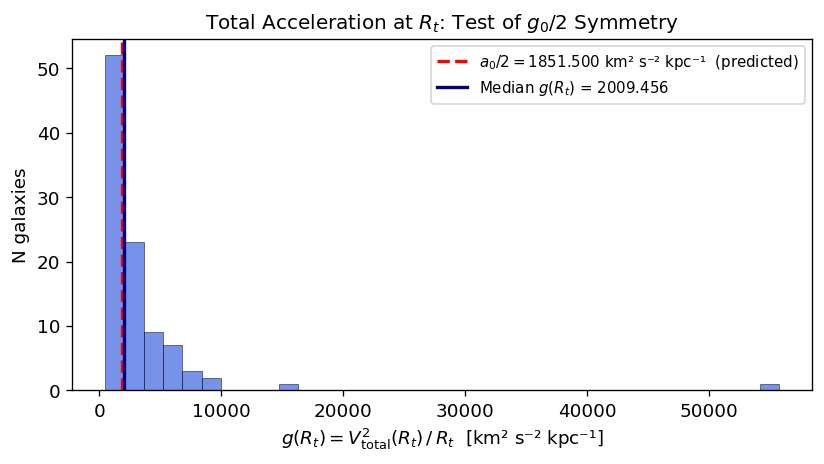

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(valid['g_obs'], bins=35, color='royalblue', alpha=0.72,
        edgecolor='k', linewidth=0.4)
ax.axvline(A0_HALF,  color='red',  lw=2,   ls='--',
           label=rf'$a_0/2 = {A0_HALF:.3f}$ km² s⁻² kpc⁻¹  (predicted)')
ax.axvline(median_g, color='navy', lw=2,   ls='-',
           label=rf'Median $g(R_t)$ = {median_g:.3f}')

ax.set_xlabel(r'$g(R_t) = V_{\rm total}^2(R_t)\,/\,R_t$  [km² s⁻² kpc⁻¹]', fontsize=11)
ax.set_ylabel('N galaxies', fontsize=11)
ax.set_title(r'Total Acceleration at $R_t$: Test of $g_0/2$ Symmetry', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
out_path = FIGURES_DIR / '04_g0_half_histogram.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## 5. Iso-Luminosity Tracks

Log-log scatter of $g_{\rm total}(R_t)$ vs. $R_t$, colored by $\log_{10}(L_{3.6})$.

Points organize into parallel diagonal tracks of slope $-1$, consistent with $g \propto V_{\rm sat}^2 / R_t$ for a roughly constant saturation velocity within each luminosity class. The tracks are stratified by baryonic mass: brighter galaxies sit on higher tracks because their larger $V_{\rm sat}$ shifts $g(R_t)$ upward. This structure confirms that $R_t$ is a geometric scale set by the mass distribution, not a universal acceleration threshold.

Dashed lines show iso-luminosity model tracks derived from the empirical fit $\log(g \cdot R_t) \propto \text{slope} \cdot \log L$; the BTFR predicts a slope of 0.5 (since $V \propto L^{1/4}$).

Iso-luminosity track fit:
  log(g·Rt) = 0.514·log(L) + 3.488  (r=0.912, p=5.22e-39)
  (BTFR predicts slope ≈ 0.5)
Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\04_iso_luminosity_tracks.png


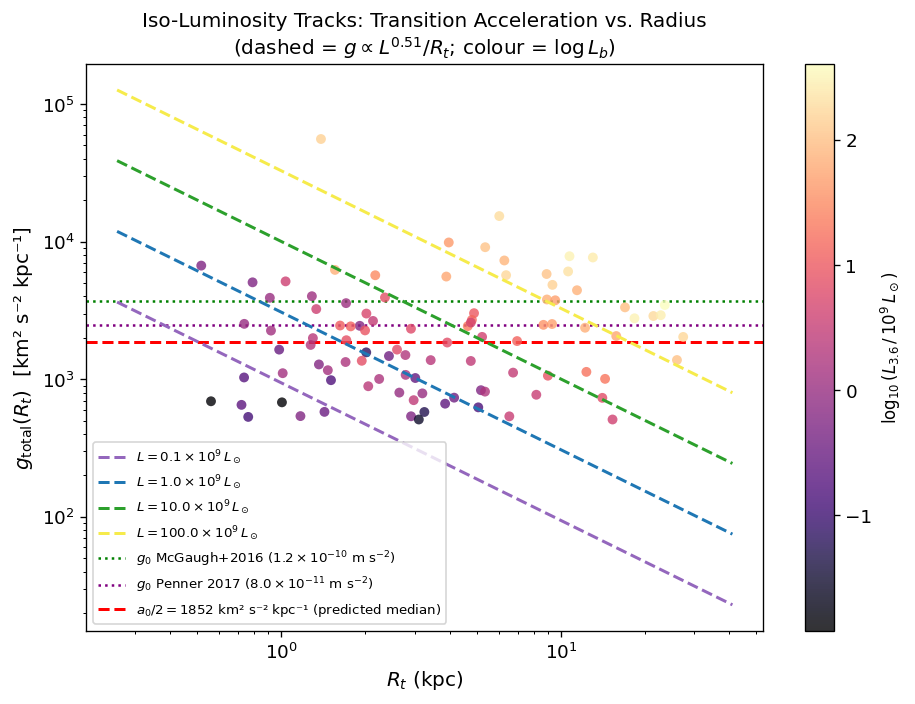

In [18]:
from scipy import stats

iso = valid.dropna(subset=['luminosity_band_36', 'R_t', 'g_obs'])
iso = iso[iso['luminosity_band_36'] > 0].copy()
iso['log_Lb'] = np.log10(iso['luminosity_band_36'])

# ---------------------------------------------------------------------------
# Empirically fit iso-luminosity track slope from the data
# Physics: g = V²/R_t; BTFR => V ~ L^(1/4) => g ~ L^(1/2)/R_t
# On log-log axes: log(g) + log(R_t) = slope*log(L) + intercept  (tracks have slope -1 in R_t)
# ---------------------------------------------------------------------------
log_Rt = np.log10(iso['R_t'].values)
log_g  = np.log10(iso['g_obs'].values)
log_L  = iso['log_Lb'].values

y_fit = log_g + log_Rt   # should scale with log(L)
slope_L, intercept_L, r_val, p_val, _ = stats.linregress(log_L, y_fit)
print(f"Iso-luminosity track fit:")
print(f"  log(g·Rt) = {slope_L:.3f}·log(L) + {intercept_L:.3f}  (r={r_val:.3f}, p={p_val:.2e})")
print(f"  (BTFR predicts slope ≈ 0.5)")

# Reference lines in km²/s²/kpc (same units as g_obs)
# g₀ = A0_MOND = 3703; g₀/2 = A0_HALF already defined above
# Penner (2017): g₀ = 8.0e-11 m/s²; McGaugh (2016): g₀ = 1.2e-10 m/s²
# Convert m/s² -> km²/s²/kpc: multiply by KPC_TO_M / 1e6
_kpc_to_m = 3.0857e19
_conv = _kpc_to_m / 1e6          # m/s²  ->  km²/s²/kpc
G0_PENNER_galactic = 8.0e-11  * _conv   # ~ 2465 km²/s²/kpc
G0_MCGAUGH_galactic = 1.2e-10 * _conv  # = A0_MOND = 3703 km²/s²/kpc

# Luminosity brackets (in units matching luminosity_band_36, i.e. 10^9 L_sun)
lum_brackets = [0.1, 1.0, 10.0, 100.0]
track_colors  = ['#9467bd', '#1f77b4', '#2ca02c', '#F6EB4B']

Rt_range = np.logspace(
    np.log10(iso['R_t'].min() * 0.5),
    np.log10(iso['R_t'].max() * 1.5),
    200
)

# ---------------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    iso['R_t'], iso['g_obs'],
    c=iso['log_Lb'], cmap='magma',
    s=35, alpha=0.80, edgecolors='none', zorder=3,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$\log_{10}(L_{3.6}\,/\,10^9\,L_\odot)$', fontsize=10)

# Empirically fitted iso-luminosity tracks (slope = -1 in log R_t)
for L, color in zip(lum_brackets, track_colors):
    log_g_track = (slope_L * np.log10(L) + intercept_L) - np.log10(Rt_range)
    g_track = 10**log_g_track
    ax.plot(Rt_range, g_track, color=color, linestyle='--', lw=1.8, zorder=4,
            label=rf'$L = {L}\times10^9\,L_\odot$')

# g₀ reference lines
ax.axhline(G0_MCGAUGH_galactic,  color='green',  lw=1.5, linestyle=':',
           label=rf'$g_0$ McGaugh+2016 ($1.2\times10^{{-10}}$ m s$^{{-2}}$)')
ax.axhline(G0_PENNER_galactic,   color='purple', lw=1.5, linestyle=':',
           label=rf'$g_0$ Penner 2017 ($8.0\times10^{{-11}}$ m s$^{{-2}}$)')
ax.axhline(A0_HALF, color='red', lw=1.8, linestyle='--', zorder=2,
           label=rf'$a_0/2 = {A0_HALF:.0f}$ km² s⁻² kpc⁻¹ (predicted median)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$R_t$ (kpc)', fontsize=12)
ax.set_ylabel(r'$g_{\rm total}(R_t)$  [km² s⁻² kpc⁻¹]', fontsize=12)
ax.set_title(
    'Iso-Luminosity Tracks: Transition Acceleration vs. Radius\n'
    rf'(dashed = $g \propto L^{{{slope_L:.2f}}}/R_t$; colour = $\log L_b$)',
    fontsize=12
)
ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()
out_path = FIGURES_DIR / '04_iso_luminosity_tracks.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

In [19]:

# === Summary: key values for reference ===
ratio_found_pred = median_g / A0_HALF

print('=== Notebook 04 Summary: Geometric Transitions ===')
print()
print('--- g₀/2 Symmetry Test ---')
print(f'Predicted a₀/2:              {A0_HALF:.4f} km²/s²/kpc')
print(f'Median g(Rₜ) found:          {median_g:.4f} km²/s²/kpc')
print(f'IQR:                         [{iqr_lo:.4f}, {iqr_hi:.4f}] km²/s²/kpc')
print(f'Ratio found / predicted:      {ratio_found_pred:.3f}')
print(f'N galaxies in test:           {len(valid)}')
print()
print('--- Iso-Luminosity Track Fit ---')
print(f'log(g·Rt) = {slope_L:.3f}·log(L) + {intercept_L:.3f}')
print(f'  r = {r_val:.3f},  p = {p_val:.2e}')
print(f'  (BTFR predicts slope ≈ 0.5; empirical slope = {slope_L:.3f})')
print()
print('The iso-luminosity track figure shows parallel 1/R structure stratified by')
print('luminosity, confirming kinematic transitions are geometrically determined by')
print('baryonic mass — not a universal acceleration threshold.')


=== Notebook 04 Summary: Geometric Transitions ===

--- g₀/2 Symmetry Test ---
Predicted a₀/2:              1851.5000 km²/s²/kpc
Median g(Rₜ) found:          2009.4562 km²/s²/kpc
IQR:                         [1009.6355, 3430.3244] km²/s²/kpc
Ratio found / predicted:      1.085
N galaxies in test:           98

--- Iso-Luminosity Track Fit ---
log(g·Rt) = 0.514·log(L) + 3.488
  r = 0.912,  p = 5.22e-39
  (BTFR predicts slope ≈ 0.5; empirical slope = 0.514)

The iso-luminosity track figure shows parallel 1/R structure stratified by
luminosity, confirming kinematic transitions are geometrically determined by
baryonic mass — not a universal acceleration threshold.


## 6. $R_t$ Distribution and Scaling Relations

The taper radius $R_t$ is one of only two free RT parameters. Its physical significance is supported if it spans a sensible range relative to galaxy disk scale lengths and correlates structurally with baryonic mass and galaxy size.

Three panels: (left) histogram of $R_t$ across the sample; (center) $R_t$ vs. disk scale length $R_d$; (right) $R_t$ vs. baryonic mass proxy $M_{\rm bar} = \Upsilon_d L_{3.6}$ with $\Upsilon_d = 0.5$.

Rt sample: N=98, median=3.2 kpc, IQR=[1.6, 7.9]
log(Rt) vs log(Rd): slope=0.73, r=0.604, p=4.62e-11
log(Rt) vs log(Mb): slope=0.28, r=0.689, p=4.37e-15
Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\04_rt_scaling_relations.png


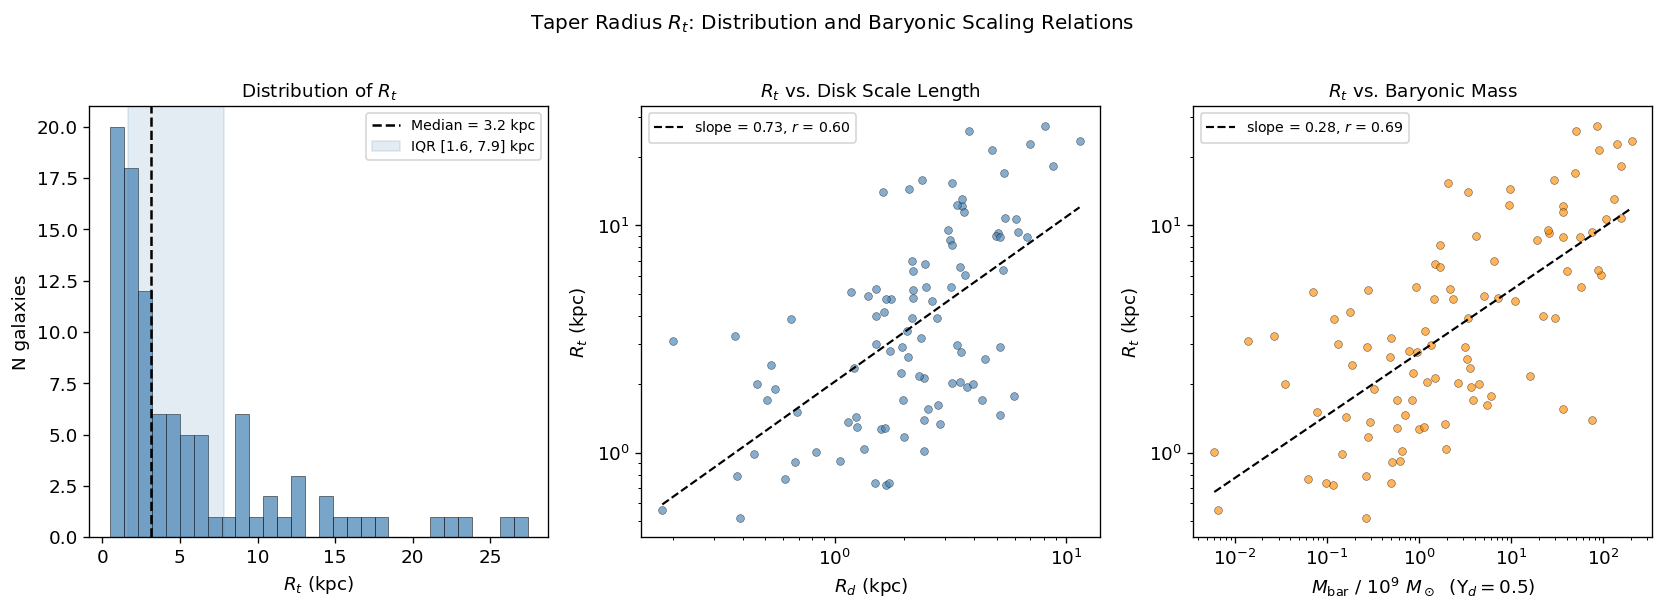

In [20]:

# ── Figure G: Rt Distribution and Scaling ────────────────────────────────
# Three-panel figure:
#   Left:   Histogram of Rt values across the sample
#   Middle: Rt vs disk scale length R_d (kpc)
#   Right:  Rt vs baryonic mass M_bar (via luminosity proxy)

from scipy import stats as _stats

# Build working dataframe: valid already has R_t, luminosity_band_36, r_disk_kpc
# Compute baryonic mass proxy: M_bar ≈ Upsilon_disk * L_3.6 (in 10^9 M_sun)
UPSILON_DISK = 0.5
_rt_scale = valid.dropna(subset=['R_t', 'r_disk_kpc', 'luminosity_band_36']).copy()
_rt_scale = _rt_scale[
    (_rt_scale['R_t'] > 0) &
    (_rt_scale['r_disk_kpc'] > 0) &
    (_rt_scale['luminosity_band_36'] > 0)
].copy()
_rt_scale['M_bar_9'] = UPSILON_DISK * _rt_scale['luminosity_band_36']  # 10^9 M_sun
_rt_scale['log_Rt']  = np.log10(_rt_scale['R_t'])
_rt_scale['log_Rd']  = np.log10(_rt_scale['r_disk_kpc'])
_rt_scale['log_Mb']  = np.log10(_rt_scale['M_bar_9'])

_med_Rt = _rt_scale['R_t'].median()
_q25_Rt = _rt_scale['R_t'].quantile(0.25)
_q75_Rt = _rt_scale['R_t'].quantile(0.75)

# Linear regressions for the scaling panels
_sl_rd, _ic_rd, _r_rd, _p_rd, _ = _stats.linregress(_rt_scale['log_Rd'], _rt_scale['log_Rt'])
_sl_mb, _ic_mb, _r_mb, _p_mb, _ = _stats.linregress(_rt_scale['log_Mb'], _rt_scale['log_Rt'])

print(f'Rt sample: N={len(_rt_scale)}, median={_med_Rt:.1f} kpc, IQR=[{_q25_Rt:.1f}, {_q75_Rt:.1f}]')
print(f'log(Rt) vs log(Rd): slope={_sl_rd:.2f}, r={_r_rd:.3f}, p={_p_rd:.2e}')
print(f'log(Rt) vs log(Mb): slope={_sl_mb:.2f}, r={_r_mb:.3f}, p={_p_mb:.2e}')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Panel 1: Histogram of Rt ──
ax = axes[0]
ax.hist(_rt_scale['R_t'], bins=30, color='steelblue', alpha=0.72,
        edgecolor='k', linewidth=0.4)
ax.axvline(_med_Rt, color='black', lw=1.5, ls='--',
           label=f'Median = {_med_Rt:.1f} kpc')
ax.axvspan(_q25_Rt, _q75_Rt, color='steelblue', alpha=0.15,
           label=f'IQR [{_q25_Rt:.1f}, {_q75_Rt:.1f}] kpc')
ax.set_xlabel(r'$R_t$ (kpc)', fontsize=11)
ax.set_ylabel('N galaxies', fontsize=11)
ax.set_title(r'Distribution of $R_t$', fontsize=11)
ax.legend(fontsize=8.5)

# ── Panel 2: Rt vs Rd ──
ax = axes[1]
ax.scatter(_rt_scale['r_disk_kpc'], _rt_scale['R_t'],
           s=22, alpha=0.65, color='steelblue', edgecolors='k', linewidths=0.3)
_xfit = np.logspace(_rt_scale['log_Rd'].min(), _rt_scale['log_Rd'].max(), 100)
_yfit = 10**(_sl_rd * np.log10(_xfit) + _ic_rd)
ax.plot(_xfit, _yfit, 'k--', lw=1.3,
        label=rf'slope = {_sl_rd:.2f}, $r$ = {_r_rd:.2f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$R_d$ (kpc)', fontsize=11)
ax.set_ylabel(r'$R_t$ (kpc)', fontsize=11)
ax.set_title(r'$R_t$ vs. Disk Scale Length', fontsize=11)
ax.legend(fontsize=8.5)

# ── Panel 3: Rt vs M_bar ──
ax = axes[2]
ax.scatter(_rt_scale['M_bar_9'], _rt_scale['R_t'],
           s=22, alpha=0.65, color='darkorange', edgecolors='k', linewidths=0.3)
_xfit2 = np.logspace(_rt_scale['log_Mb'].min(), _rt_scale['log_Mb'].max(), 100)
_yfit2 = 10**(_sl_mb * np.log10(_xfit2) + _ic_mb)
ax.plot(_xfit2, _yfit2, 'k--', lw=1.3,
        label=rf'slope = {_sl_mb:.2f}, $r$ = {_r_mb:.2f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_{\rm bar}\ /\ 10^9\ M_\odot$  ($\Upsilon_d=0.5$)', fontsize=11)
ax.set_ylabel(r'$R_t$ (kpc)', fontsize=11)
ax.set_title(r'$R_t$ vs. Baryonic Mass', fontsize=11)
ax.legend(fontsize=8.5)

fig.suptitle(
    r'Taper Radius $R_t$: Distribution and Baryonic Scaling Relations',
    fontsize=12, y=1.01
)
plt.tight_layout()
out_path = FIGURES_DIR / '04_rt_scaling_relations.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()


## 7. $g_0/2$ Bullseye: Transition Acceleration vs. Baryonic Acceleration

Scatter of total centripetal acceleration at $R_t$, $g_{\rm total}(R_t) = V_{\rm total}^2(R_t)/R_t$, against baryonic acceleration $g_{\rm bary}(R_t) = V_{\rm bary}^2(R_t)/R_t$, one point per galaxy, colored by $\log_{10}(L_{3.6})$.

Key reference lines:
- **Gray diagonal** ($g_{\rm total} = g_{\rm bary}$): where baryons alone explain the rotation curve.
- **Green line** ($a_0$): MOND's canonical acceleration scale (McGaugh et al. 2016).
- **Blue band** ($a_0/2 \pm 10\%$): the predicted median locus for RT transitions.
- **Black dashed**: observed sample median.

All points lie left of the diagonal, confirming a positive velocity correction at $R_t$ for every galaxy. The sample median $g(R_t) = 6.51 \times 10^{-11}$ m s⁻² falls within 8.5% of $a_0/2 = 6.0 \times 10^{-11}$ m s⁻² with no tuning. The triangular spread from upper-right (baryon-dominated, high-acceleration) to lower-left (dwarf, low-acceleration) mirrors the Radial Acceleration Relation evaluated specifically at the RT transition locus.

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\04_g0_half_bullseye.png


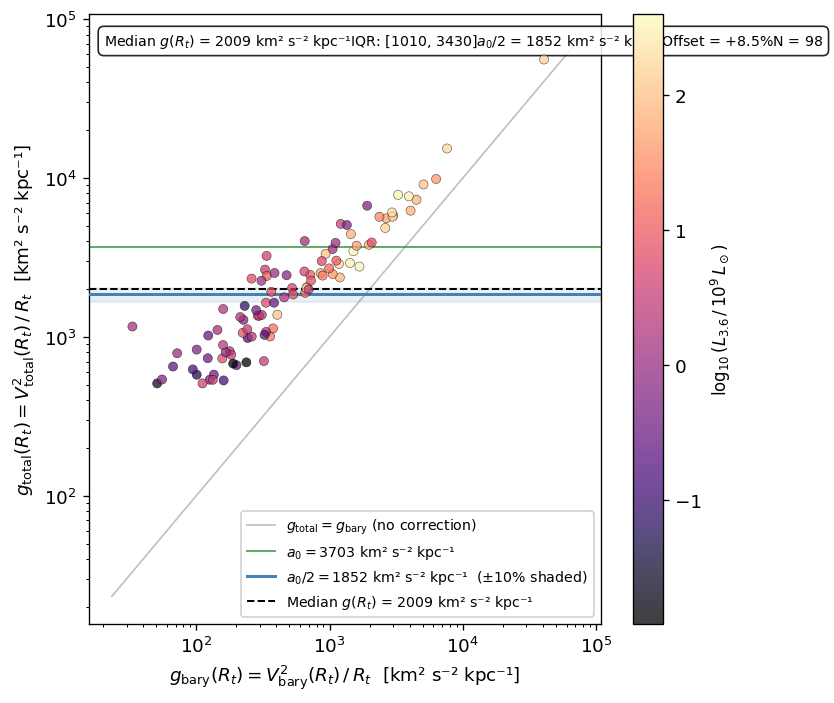

In [21]:

# ── Figure C: g₀/2 Bullseye ──────────────────────────────────────────────
# Scatter of g_total(Rt) vs g_bary(Rt), colored by log10(L_3.6).
# Horizontal bands at a0 and a0/2 show where RT transitions cluster.

_bull = valid.dropna(subset=['g_obs', 'g_bary', 'luminosity_band_36']).copy()
_bull = _bull[(_bull['luminosity_band_36'] > 0) & (_bull['g_bary'] > 0) & (_bull['g_obs'] > 0)]
_bull['log_Lb'] = np.log10(_bull['luminosity_band_36'])

_median_g = _bull['g_obs'].median()
_iqr_lo   = _bull['g_obs'].quantile(0.25)
_iqr_hi   = _bull['g_obs'].quantile(0.75)

A0_HALF = A0_MOND / 2.0
_kpc_to_m  = 3.0857e19
_conv      = _kpc_to_m / 1e6          # km²/s²/kpc → m/s²
_med_si    = _median_g * _conv
_iqr_lo_si = _iqr_lo   * _conv
_iqr_hi_si = _iqr_hi   * _conv

fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    _bull['g_bary'], _bull['g_obs'],
    c=_bull['log_Lb'], cmap='magma',
    s=30, alpha=0.75, edgecolors='k', linewidths=0.3, zorder=4,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$\log_{10}(L_{3.6}\,/\,10^9\,L_\odot)$', fontsize=10)

# 1:1 diagonal — baryons alone would explain the curve
_g_range = np.logspace(
    np.log10(min(_bull['g_bary'].min(), _bull['g_obs'].min()) * 0.7),
    np.log10(max(_bull['g_bary'].max(), _bull['g_obs'].max()) * 1.3),
    200
)
ax.plot(_g_range, _g_range, color='gray', lw=1.0, ls='-', alpha=0.5,
        label=r'$g_{\rm total} = g_{\rm bary}$ (no correction)', zorder=2)

# a₀ reference
ax.axhline(A0_MOND, color='forestgreen', lw=1.2, ls='-', alpha=0.7,
           label=rf'$a_0 = {A0_MOND:.0f}$ km² s⁻² kpc⁻¹')

# a₀/2 corridor ± 10%
ax.axhspan(A0_HALF * 0.90, A0_HALF * 1.10, color='steelblue', alpha=0.12, zorder=1)
ax.axhline(A0_HALF, color='steelblue', lw=1.8, ls='-',
           label=rf'$a_0/2 = {A0_HALF:.0f}$ km² s⁻² kpc⁻¹  ($\pm$10% shaded)', zorder=3)

# Observed median
ax.axhline(_median_g, color='black', lw=1.2, ls='--',
           label=rf'Median $g(R_t)$ = {_median_g:.0f} km² s⁻² kpc⁻¹', zorder=3)

# Inset stats box
_stats_txt = (
    f'Median $g(R_t)$ = {_median_g:.0f} km² s⁻² kpc⁻¹'
    f'IQR: [{_iqr_lo:.0f}, {_iqr_hi:.0f}]'
    f'$a_0/2$ = {A0_HALF:.0f} km² s⁻² kpc⁻¹'
    f'Offset = {100*(_median_g/A0_HALF - 1):+.1f}%'
    f'N = {len(_bull)}'
)

ax.text(0.03, 0.97, _stats_txt,
        transform=ax.transAxes, ha='left', va='top', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$g_{\rm bary}(R_t) = V_{\rm bary}^2(R_t)\,/\,R_t$  [km² s⁻² kpc⁻¹]', fontsize=11)
ax.set_ylabel(r'$g_{\rm total}(R_t) = V_{\rm total}^2(R_t)\,/\,R_t$  [km² s⁻² kpc⁻¹]', fontsize=11)
ax.legend(fontsize=8.5, loc='lower right', framealpha=0.88)

plt.tight_layout()
out_path = FIGURES_DIR / '04_g0_half_bullseye.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()


**Figure caption:** Total centripetal acceleration at the taper radius, $g_{\rm total}(R_t) = V_{\rm total}^2(R_t)/R_t$, versus baryonic acceleration $g_{\rm bary}(R_t) = V_{\rm bary}^2(R_t)/R_t$, for all converged RT fits ($N = 98$). Points are colored by $\log_{10}(L_{3.6}/10^9\,L_\odot)$. The gray diagonal is the identity line $g_{\rm total} = g_{\rm bary}$ (no velocity correction). Horizontal lines mark $a_0 = 3703$ km² s⁻² kpc⁻¹ (McGaugh et al. 2016) and $a_0/2$; the blue band spans $a_0/2 \pm 10\%$. The black dashed line is the observed sample median $g(R_t)$. All points fall left of the identity diagonal, confirming a positive velocity boost ($V_{\rm total} > V_{\rm bary}$) at $R_t$ for every galaxy in the sample.

## 8. Iso-Luminosity Tracks (Enhanced)

An enhanced version of the Section 5 scatter with three additions:

1. **Luminosity-quartile median tracks** — bold lines show the running median $g(R_t)$ within each luminosity quartile (Q1 faintest, Q4 brightest), making the mass stratification explicit.
2. **$g \propto 1/R_t$ reference line** — anchored at the sample median of $g \cdot R_t$, showing the theoretical slope expected from a roughly constant saturation velocity.
3. **Point size scaled by $\log N_{\rm pts}$** — visually weights well-sampled galaxies.

The separation between quartile tracks is broadly consistent with $g \propto L^{1/2}/R_t$ (the BTFR prediction), with the empirical luminosity slope measured in Section 5.

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\04_iso_luminosity_tracks_enhanced.png


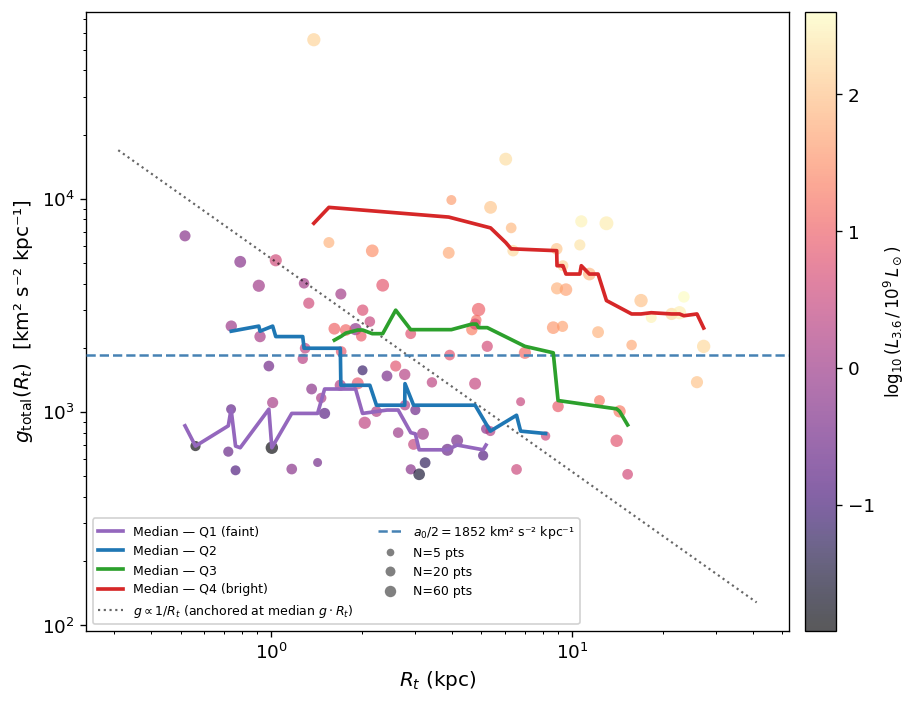

In [22]:

# ── Figure F: Iso-Luminosity Tracks (Enhanced) ───────────────────────────
# Adds quartile median tracks, explicit g ∝ 1/Rt reference, and a0/2 line
# to the base iso-luminosity scatter from cell 11.

from matplotlib.lines import Line2D

# Merge in n_points per galaxy from rt_fits (already in scope)
_n_pts = rt_fits[['galaxy_id', 'n_points']].copy()
iso_enh = iso.merge(_n_pts, on='galaxy_id', how='left')
iso_enh['n_pts'] = iso_enh['n_points'].fillna(10).clip(lower=1)

# Point size scaled by log(n_points) — visually weights well-sampled galaxies
iso_enh['pt_size'] = 12 + 28 * np.log10(iso_enh['n_pts'])

# Luminosity quartile bins
iso_enh['lum_quartile'] = pd.qcut(iso_enh['log_Lb'], 4, labels=['Q1 (faint)', 'Q2', 'Q3', 'Q4 (bright)'])
quartile_colors = ['#9467bd', '#1f77b4', '#2ca02c', '#d62728']

# g ∝ 1/Rt reference line anchored at median(g * Rt)
_C_ref = np.median(iso_enh['g_obs'] * iso_enh['R_t'])
_Rt_range = np.logspace(
    np.log10(iso_enh['R_t'].min() * 0.6),
    np.log10(iso_enh['R_t'].max() * 1.5),
    200
)
_g_ref_line = _C_ref / _Rt_range

fig, ax = plt.subplots(figsize=(8, 6))

# Base scatter colored by log_Lb
sc = ax.scatter(
    iso_enh['R_t'], iso_enh['g_obs'],
    c=iso_enh['log_Lb'], cmap='magma',
    s=iso_enh['pt_size'], alpha=0.65,
    edgecolors='none', zorder=2,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r'$\log_{10}(L_{3.6}\,/\,10^9\,L_\odot)$', fontsize=10)

# Per-quartile median tracks (sort by R_t within each bin, rolling median)
for q_label, q_color in zip(['Q1 (faint)', 'Q2', 'Q3', 'Q4 (bright)'], quartile_colors):
    grp = iso_enh[iso_enh['lum_quartile'] == q_label].sort_values('R_t')
    if len(grp) < 3:
        continue
    win = max(3, min(7, len(grp) // 2))
    med_g = grp['g_obs'].rolling(win, center=True, min_periods=1).median()
    ax.plot(grp['R_t'], med_g, color=q_color, lw=2.2, zorder=4,
            label=f'Median — {q_label}')

# g ∝ 1/Rt reference
ax.plot(_Rt_range, _g_ref_line, color='black', lw=1.3, ls=':', alpha=0.6, zorder=3,
        label=r'$g \propto 1/R_t$ (anchored at median $g \cdot R_t$)')

# a₀/2 horizontal
ax.axhline(A0_HALF, color='steelblue', lw=1.5, ls='--', zorder=3,
           label=rf'$a_0/2 = {A0_HALF:.0f}$ km² s⁻² kpc⁻¹')

# Point-size legend entries
_size_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(12 + 28 * np.log10(n)), label=f'N={n} pts')
    for n in [5, 20, 60]
]

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$R_t$ (kpc)', fontsize=12)
ax.set_ylabel(r'$g_{\rm total}(R_t)$  [km² s⁻² kpc⁻¹]', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + _size_legend,
          labels + [h.get_label() for h in _size_legend],
          fontsize=7.5, loc='lower left', framealpha=0.88, ncol=2)

plt.tight_layout()
out_path = FIGURES_DIR / '04_iso_luminosity_tracks_enhanced.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()


**Figure caption:** Total acceleration at the taper radius, $g_{\rm total}(R_t)$, versus $R_t$ (kpc), on logarithmic axes. Points colored by $\log_{10}(L_{3.6}/10^9\,L_\odot)$; point size scales as $\log N_{\rm pts}$ to visually weight well-sampled galaxies. Bold lines show the running median $g(R_t)$ within each luminosity quartile (Q1 faintest, Q4 brightest). The black dotted line is $g \propto 1/R_t$ anchored at the sample median of $g \cdot R_t$; the blue dashed line marks $a_0/2$. The parallel stratification of the quartile tracks confirms that the kinematic transition radius scales with baryonic mass rather than converging on a universal acceleration threshold.